In [7]:
from IPython.display import clear_output
import numpy as np
np.set_printoptions(linewidth=10000)
import matplotlib.pyplot as plt

from importnb import Notebook

with Notebook():
    import lipm

## ZMP Reference
The OC permits us to track a reference for the ZMP. We design a reference for the $Y$ plane, i.e., stepping in place. The robot steps first to the left, then to the right, and finally it goes back with both feet on the ground (ZMP in the center). References are generated for all the nodes in the horizon.

In [8]:
# We consider the position of the left and right foot on the y to be -0.1 and 0.1 respectively.
def zmp_ref(ns):
    zref = np.zeros((2, ns))
    for i in range(ns):
        zref[:, i] = np.zeros((2, 1)).flatten()
        if i >= 10 and i < 20:
            zref[:, i] = np.array([0.0, 0.1])
        elif i >= 20 and i < 30:
            zref[:, i] = np.array([0.0, -0.1])
        elif i >= 30:
            zref[:, i] = np.array([0.0, 0.])
    return zref

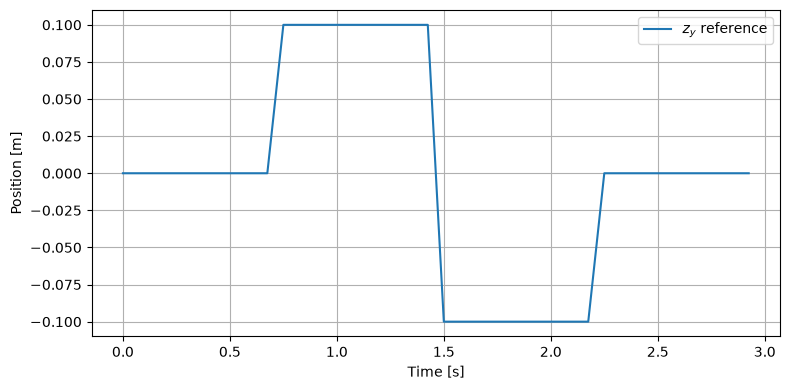

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(lipm.ns) * lipm.dt, zmp_ref(lipm.ns)[1,:], label='$z_y$ reference')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()